# Car Price Prediction using Ridge and LASSO,

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [3]:
df.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


## Step 1. Data Understanding and EDA

In [4]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
# Checkpoint 1
dfAnalysis = df.copy()
categorical_variables = dfAnalysis.select_dtypes(include=["object"])

In [7]:
numerical_variables = dfAnalysis.select_dtypes(include=["int64", "float64"])

In [8]:
categorical_variables.value_counts()

CarName               fueltype  aspiration  doornumber  carbody    drivewheel  enginelocation  enginetype  cylindernumber  fuelsystem
peugeot 504           gas       std         four        sedan      rwd         front           l           four            mpfi          3
honda civic           gas       std         two         hatchback  fwd         front           ohc         four            1bbl          2
volvo 145e (sw)       gas       std         four        sedan      rwd         front           ohc         four            mpfi          2
toyota mark ii        gas       std         four        sedan      fwd         front           ohc         four            2bbl          2
mitsubishi mirage g4  gas       turbo       two         hatchback  fwd         front           ohc         four            spdi          2
                                                                                                                                        ..
mazda glc deluxe      diesel    

In [56]:
def descriptive_statistics():
    pass


dfAnalysis.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Analysis based on Descriptive Statistics
Based on the descriptive statistics provided, we can draw several inferences about the dataset:
#### Symboling:
- Range: -2 to 3.
- Distribution Insight: Contains negative values which need to be cleaned up


In [51]:
x = pd.DataFrame()
if numerical_variables[numerical_variables["symboling"] < 0].shape[0]:
    x = pd.concat([x, numerical_variables["symboling"]], axis=1)

In [45]:
dfAnalysis["Brand"] = dfAnalysis["CarName"].str.split(" ", expand=True)[0]

In [57]:
dfAnalysis.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000,audi
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000,audi
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000,audi
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000,audi
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000,audi
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167,audi


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [65]:
# Function to calculate unique values
def unique_values_percentage(df, columns):
    results = {}
    for column in columns:
        # Count unique values and calculate percentages
        value_counts = df[column].value_counts()
        percentages = df[column].value_counts(normalize=True) * 100

        # Combine counts and percentages into a DataFrame
        unique_summary = pd.DataFrame(
            {"Count": value_counts, "Percentage (%)": percentages}
        )

        # Add the result to the dictionary
        results[column] = unique_summary

    return results


# List of columns to analyze
selected_columns = dfAnalysis.select_dtypes(include=["object"]).columns.tolist()
selected_columns.remove("CarName")
# Get unique values and their percentages for the selected columns
unique_values_summary = unique_values_percentage(dfAnalysis, selected_columns)

# Display the results for each column
for column, summary in unique_values_summary.items():
    print(f"\nUnique values and percentages for column: {column}")
    print(summary)


Unique values and percentages for column: fueltype
          Count  Percentage (%)
fueltype                       
gas         185       90.243902
diesel       20        9.756098

Unique values and percentages for column: aspiration
            Count  Percentage (%)
aspiration                       
std           168        81.95122
turbo          37        18.04878

Unique values and percentages for column: doornumber
            Count  Percentage (%)
doornumber                       
four          115       56.097561
two            90       43.902439

Unique values and percentages for column: carbody
             Count  Percentage (%)
carbody                           
sedan           96       46.829268
hatchback       70       34.146341
wagon           25       12.195122
hardtop          8        3.902439
convertible      6        2.926829

Unique values and percentages for column: drivewheel
            Count  Percentage (%)
drivewheel                       
fwd           120     

### Feature Engineering (Feature creation/modification)

- We would convert aspiration, doornumber, carbody into numeric values
- We have created a brand column from CarName which we can drop
- We can drop CarId, as it does not provide any useful information
-

In [71]:
# Dropping CarName and CarID
dfAnalysis.drop(["CarName", "car_ID"], axis=1, inplace=True)

In [72]:
dfAnalysis[dfAnalysis["symboling"] < 0]

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
28,-1,gas,std,four,wagon,fwd,front,103.3,174.6,64.6,...,2bbl,3.34,3.46,8.5,88,5000,24,30,8921.0,dodge
67,-1,diesel,turbo,four,sedan,rwd,front,110.0,190.9,70.3,...,idi,3.58,3.64,21.5,123,4350,22,25,25552.0,buick
68,-1,diesel,turbo,four,wagon,rwd,front,110.0,190.9,70.3,...,idi,3.58,3.64,21.5,123,4350,22,25,28248.0,buick
70,-1,diesel,turbo,four,sedan,rwd,front,115.6,202.6,71.7,...,idi,3.58,3.64,21.5,123,4350,22,25,31600.0,buick
71,-1,gas,std,four,sedan,rwd,front,115.6,202.6,71.7,...,mpfi,3.46,3.10,8.3,155,4750,16,18,34184.0,buick
88,-1,gas,std,four,sedan,fwd,front,96.3,172.4,65.4,...,spdi,3.17,3.46,7.5,116,5500,23,30,9279.0,mitsubishi
123,-1,gas,std,four,wagon,fwd,front,103.3,174.6,64.6,...,2bbl,3.35,3.46,8.5,88,5000,24,30,8921.0,plymouth
173,-1,gas,std,four,sedan,fwd,front,102.4,175.6,66.5,...,mpfi,3.31,3.54,8.7,92,4200,29,34,8948.0,toyota
174,-1,diesel,turbo,four,sedan,fwd,front,102.4,175.6,66.5,...,idi,3.27,3.35,22.5,73,4500,30,33,10698.0,toyota
175,-1,gas,std,four,hatchback,fwd,front,102.4,175.6,66.5,...,mpfi,3.31,3.54,8.7,92,4200,27,32,9988.0,toyota


In [78]:
categorical_variables = dfAnalysis.select_dtypes(include=["object"]).columns.tolist()
pd.get_dummies(dfAnalysis[categorical_variables], dtype=int).head()

,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,doornumber_four,doornumber_two,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,...,Brand_porsche,Brand_renault,Brand_saab,Brand_subaru,Brand_toyota,Brand_toyouta,Brand_vokswagen,Brand_volkswagen,Brand_volvo,Brand_vw
0,0,1,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [79]:
dfAnalysis.to_csv("CarPrice.csv")

In [80]:
dfAnalysis.columns.tolist()

['symboling',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginetype',
 'cylindernumber',
 'enginesize',
 'fuelsystem',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price',
 'Brand']

In [81]:
dfAnalysis.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi



Correlation matrix for numerical columns with 'price':
price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


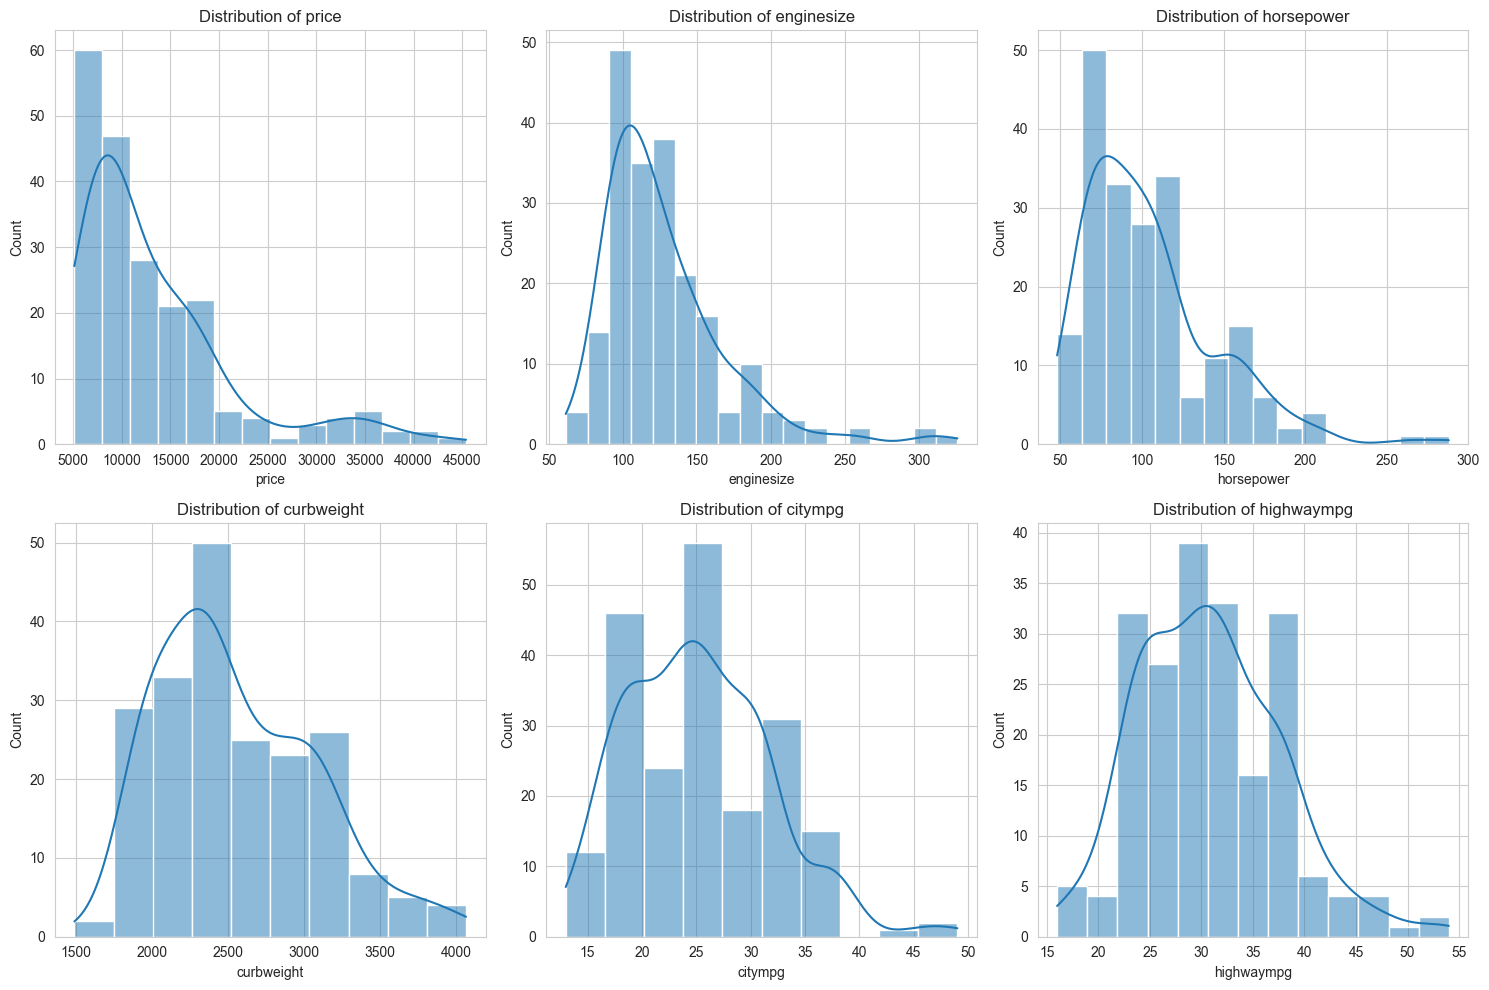

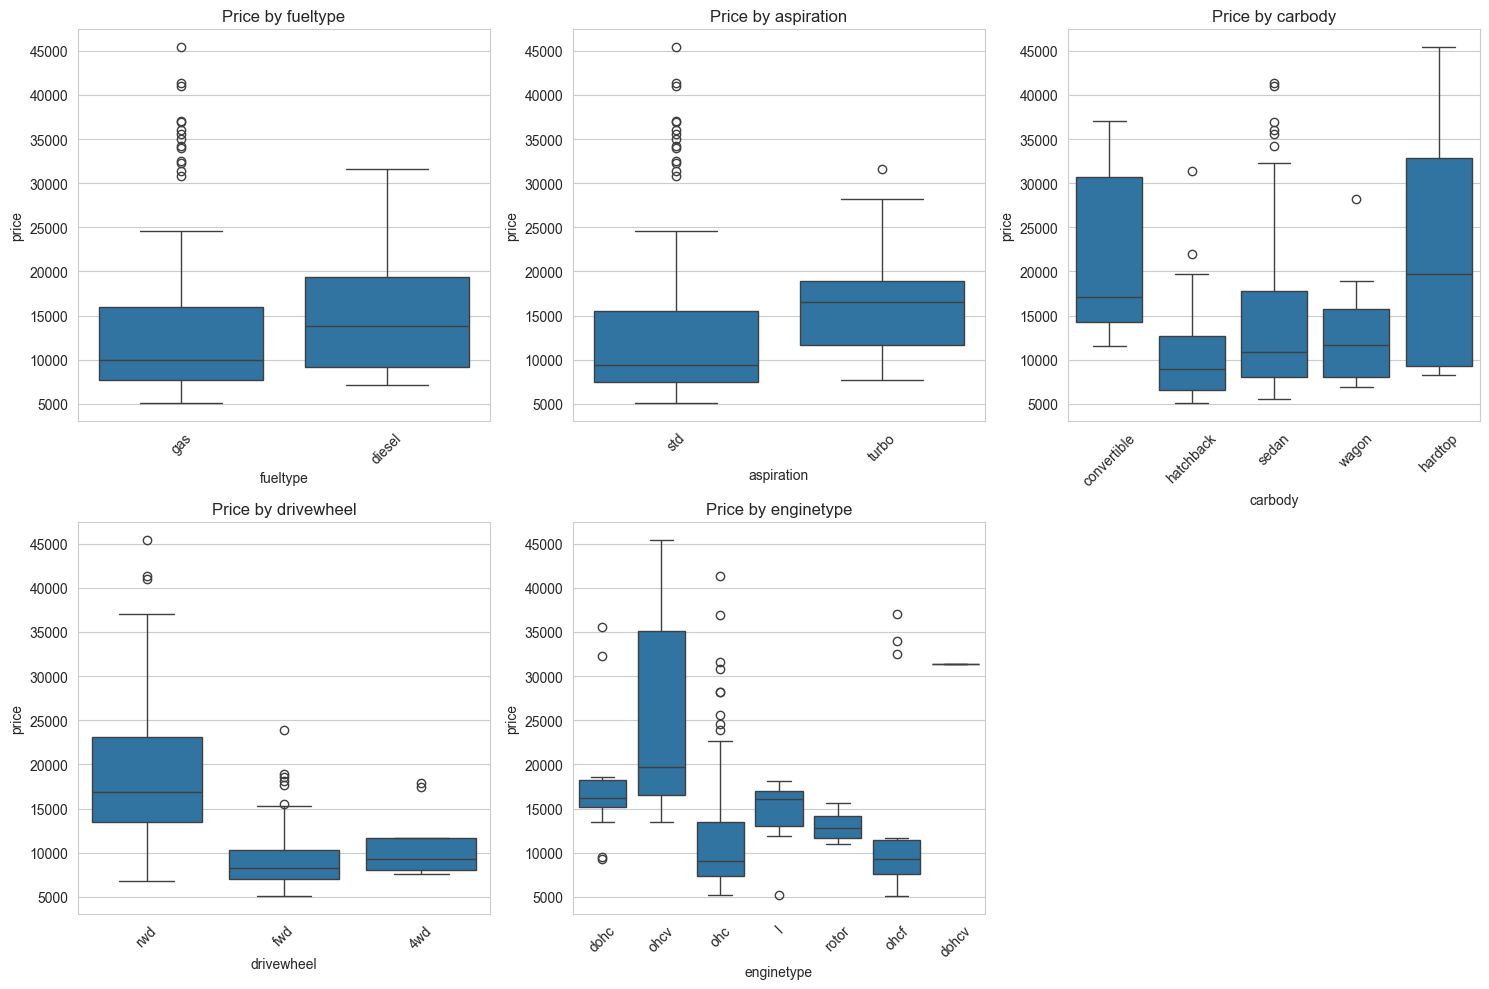

In [85]:
numerical_for_corr = [
    col
    for col in numerical_variables
    if col != "symboling" and col != "price" and col != "car_ID"
]

print("\nCorrelation matrix for numerical columns with 'price':")
print(
    dfAnalysis[numerical_for_corr + ["price"]]
    .corr()["price"]
    .sort_values(ascending=False)
)

# Plotting histograms for key numerical features to visualize distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(
    ["price", "enginesize", "horsepower", "curbweight", "citympg", "highwaympg"], 1
):
    plt.subplot(2, 3, i)
    sns.histplot(dfAnalysis[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("numerical_distributions.png")

# Plotting box plots for the relationship between some categorical features and 'price'
plt.figure(figsize=(15, 10))
for i, col in enumerate(
    ["fueltype", "aspiration", "carbody", "drivewheel", "enginetype"], 1
):
    plt.subplot(2, 3, i)
    sns.boxplot(x=col, y="price", data=df)
    plt.title(f"Price by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()

In [87]:
dfAnalysis["power_to_weight_ratio"] = (
    dfAnalysis["horsepower"] / dfAnalysis["curbweight"]
)

In [92]:
variables_to_dummies = [
    "fueltype",
    "aspiration",
    "carbody",
    "drivewheel",
    "enginetype",
]  # 'fuelsystem','enginelocation','doornumber'
dfAnalysis = pd.concat(
    [
        dfAnalysis,
        pd.get_dummies(dfAnalysis[variables_to_dummies], drop_first=True, dtype=int),
    ],
    axis=1,
)

In [94]:
dfAnalysis.drop(variables_to_dummies, axis=1, inplace=True)

In [95]:
dfAnalysis

,symboling,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,...,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,3,two,front,88.6,168.8,64.1,48.8,2548,four,130,...,0,0,0,1,0,0,0,0,0,0
1,3,two,front,88.6,168.8,64.1,48.8,2548,four,130,...,0,0,0,1,0,0,0,0,0,0
2,1,two,front,94.5,171.2,65.5,52.4,2823,six,152,...,0,0,0,1,0,0,0,0,1,0
3,2,four,front,99.8,176.6,66.2,54.3,2337,four,109,...,1,0,1,0,0,0,1,0,0,0
4,2,four,front,99.4,176.6,66.4,54.3,2824,five,136,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,four,front,109.1,188.8,68.9,55.5,2952,four,141,...,1,0,0,1,0,0,1,0,0,0
201,-1,four,front,109.1,188.8,68.8,55.5,3049,four,141,...,1,0,0,1,0,0,1,0,0,0
202,-1,four,front,109.1,188.8,68.9,55.5,3012,six,173,...,1,0,0,1,0,0,0,0,1,0
203,-1,four,front,109.1,188.8,68.9,55.5,3217,six,145,...,1,0,0,1,0,0,1,0,0,0


In [98]:
dfAnalysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   doornumber             205 non-null    object 
 2   enginelocation         205 non-null    object 
 3   wheelbase              205 non-null    float64
 4   carlength              205 non-null    float64
 5   carwidth               205 non-null    float64
 6   carheight              205 non-null    float64
 7   curbweight             205 non-null    int64  
 8   cylindernumber         205 non-null    object 
 9   enginesize             205 non-null    int64  
 10  fuelsystem             205 non-null    object 
 11  boreratio              205 non-null    float64
 12  stroke                 205 non-null    float64
 13  compressionratio       205 non-null    float64
 14  horsepower             205 non-null    int64  
 15  peakrp

In [101]:
dfAnalysis = pd.concat(
    [dfAnalysis, pd.get_dummies(dfAnalysis["enginelocation"], dtype=int)], axis=1
)
dfAnalysis.drop(["enginelocation", "rear"], axis=1, inplace=True)

In [102]:
dfAnalysis.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,fuelsystem,...,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,front
0,3,two,88.6,168.8,64.1,48.8,2548,four,130,mpfi,...,0,0,1,0,0,0,0,0,0,1
1,3,two,88.6,168.8,64.1,48.8,2548,four,130,mpfi,...,0,0,1,0,0,0,0,0,0,1
2,1,two,94.5,171.2,65.5,52.4,2823,six,152,mpfi,...,0,0,1,0,0,0,0,1,0,1
3,2,four,99.8,176.6,66.2,54.3,2337,four,109,mpfi,...,0,1,0,0,0,1,0,0,0,1
4,2,four,99.4,176.6,66.4,54.3,2824,five,136,mpfi,...,0,0,0,0,0,1,0,0,0,1


In [106]:
dfAnalysis = pd.concat(
    [dfAnalysis, pd.get_dummies(dfAnalysis["fuelsystem"], drop_first=True, dtype=int)],
    axis=1,
)
dfAnalysis.drop("fuelsystem", axis=1, inplace=True)

In [ ]:
dfAnalysis = pd.concat(
    [dfAnalysis, pd.get_dummies(dfAnalysis["doornumber"], drop_first=True, dtype=int)],
    axis=1,
)

Brand
toyota         31
nissan         17
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
volkswagen      9
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
chevrolet       3
jaguar          3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
Nissan          1
mercury         1
porcshce        1
Name: count, dtype: int64

## Model Building

In [115]:
dfModel = dfAnalysis.copy()

In [117]:
# Importing libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV

In [118]:
features = [col for col in dfModel.columns.tolist() if col != "price"]
X = dfModel[features]
y = dfModel["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [119]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(143, 39) (62, 39) (143,) (62,)


In [120]:
help(RobustScaler)

Help on class RobustScaler in module sklearn.preprocessing._data:

class RobustScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  RobustScaler(
 |      *,
 |      with_centering=True,
 |      with_scaling=True,
 |      quantile_range=(25.0, 75.0),
 |      copy=True,
 |      unit_variance=False
 |  )
 |
 |  Scale features using statistics that are robust to outliers.
 |
 |  This Scaler removes the median and scales the data according to
 |  the quantile range (defaults to IQR: Interquartile Range).
 |  The IQR is the range between the 1st quartile (25th quantile)
 |  and the 3rd quartile (75th quantile).
 |
 |  Centering and scaling happen independently on each feature by
 |  computing the relevant statistics on the samples in the training
 |  set. Median and interquartile range are then stored to be used on
 |  later data using the :meth:`transform` method.
 |
 |  Standardization of a dataset is a common preprocessing for many machi

In [122]:
numerical_variables

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470.0


In [139]:
scaler = RobustScaler()
num_var = [
    "wheelbase",
    "carlength",
    "carwidth",
    "carheight",
    "curbweight",
    "carheight",
    "enginesize",
    "boreratio",
    "stroke",
    "compressionratio",
    "horsepower",
    "peakrpm",
    "citympg",
    "highwaympg",
    "power_to_weight_ratio",
]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_var] = scaler.fit_transform(X_train[num_var])
X_test_scaled[num_var] = scaler.transform(X_test[num_var])

In [144]:
X_train_scaled.drop(["Brand", "cylindernumber"], axis=1, inplace=True)
X_test_scaled.drop(["Brand", "cylindernumber"], axis=1, inplace=True)

In [145]:
X_train_scaled.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,enginetype_ohcv,enginetype_rotor,front,2bbl,4bbl,idi,mfi,mpfi,spdi,spfi
177,-1,0.675325,0.123596,0.370370,-0.054054,0.019672,0.046512,0.000000,0.931034,-0.352941,...,0,0,1,0,0,0,0,1,0,0
75,1,0.714286,0.280899,0.925926,0.189189,0.612459,0.465116,1.205128,-0.517241,-1.176471,...,0,0,1,0,0,0,0,1,0,0
174,-1,0.675325,0.123596,0.370370,0.216216,0.048525,-0.232558,-0.102564,0.275862,15.882353,...,0,0,1,0,0,1,0,0,0,0
31,2,-1.376623,-1.617978,-0.592593,-0.891892,-0.818361,-0.651163,-1.025641,0.482759,0.235294,...,0,0,1,0,0,0,0,0,0,0
12,0,0.519481,0.191011,-0.259259,0.054054,0.350164,1.023256,0.000000,-0.275862,0.000000,...,0,0,1,0,0,0,0,1,0,0


In [146]:
# Model building
lm = LinearRegression()
lm.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_pred = lm.predict(X_test_scaled)

In [148]:
from sklearn import metrics

In [149]:
y_train_pred = lm.predict(X_train_scaled)
print(f"Train accuracy: {metrics.r2_score(y_train,y_train_pred)}")
print(f"Test accuracy: {metrics.r2_score(y_test,y_pred)}")

Train accuracy: 0.9421226699284311
Test accuracy: 0.8385079180109634


In [151]:
def goodness_of_fit(y_true, predictions):
    # RSS
    rss = np.sum(np.square(y_true - predictions))
    # MSE
    mse = metrics.mean_squared_error(y_true=y_true, y_pred=predictions)
    rmse = np.sqrt(mse)
    return rss, mse, rmse


print(f"Test values: {goodness_of_fit(y_test,y_pred)}")

Test values: (np.float64(693710470.1776154), 11188878.551251862, np.float64(3344.978109233581))


In [152]:
print(f"Train Values: {goodness_of_fit(y_train,y_train_pred)}")

Train Values: (np.float64(504446958.8242178), 3527601.110658866, np.float64(1878.190914326567))


In [154]:
# it will not handle the overfitting
params = {
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        6.0,
        7.0,
        8.0,
        9.0,
        10.0,
        20,
        50,
        100,
        500,
        1000,
    ]
}

ridge = Ridge()

# cross validation
folds = 5
model_cv = GridSearchCV(
    estimator=ridge,
    param_grid=params,
    scoring="neg_mean_absolute_error",
    cv=folds,
    return_train_score=True,
    verbose=1,
)
model_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Ridge()
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,0.5


In [157]:
dir(model_cv)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_refit_for_multimetric',
 '_check_scorers_accept_sample_weight',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr

In [160]:
results = pd.DataFrame(model_cv.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.002627,0.003276,0.000531,1.377067e-04,0.0001,{'alpha': 0.0001},-2498.224275,-2031.352758,-1903.434499,-2273.257387,...,-2186.733110,205.215923,23,-1259.221787,-1331.843182,-1383.280151,-1292.398981,-1393.362054,-1332.021231,51.497353
1,0.000675,0.000029,0.000394,1.605575e-05,0.0010,{'alpha': 0.001},-2495.185513,-2029.576506,-1903.428140,-2272.837696,...,-2185.584959,204.510797,22,-1259.612515,-1332.186110,-1383.301249,-1292.545802,-1393.542136,-1332.237562,51.411257
2,0.000769,0.000136,0.000423,3.484959e-05,0.0100,{'alpha': 0.01},-2467.167551,-2012.406941,-1902.986307,-2270.945711,...,-2175.105765,198.598314,19,-1263.282217,-1335.463559,-1383.599776,-1293.953634,-1395.268993,-1334.313636,50.636733
3,0.000696,0.000016,0.000411,6.583116e-06,0.0500,{'alpha': 0.05},-2377.021768,-1946.822604,-1895.337299,-2267.569042,...,-2139.325872,186.821453,15,-1277.107599,-1348.053945,-1386.630731,-1302.984630,-1404.020001,-1343.759381,48.151383
4,0.000728,0.000023,0.000449,3.963851e-05,0.1000,{'alpha': 0.1},-2303.678472,-1882.055928,-1883.983394,-2270.068415,...,-2110.921079,188.232874,12,-1297.225589,-1360.814754,-1396.149386,-1312.145008,-1413.606429,-1355.988233,45.456235
5,0.000769,0.000107,0.000438,6.877430e-05,0.2000,{'alpha': 0.2},-2258.800694,-1799.093602,-1856.011166,-2283.635076,...,-2084.107556,211.130379,9,-1335.416401,-1382.507837,-1415.461768,-1329.371292,-1429.658158,-1378.483091,40.667474
6,0.000703,0.000009,0.000409,7.599534e-07,0.3000,{'alpha': 0.3},-2244.556059,-1747.587070,-1826.058343,-2296.445148,...,-2069.018415,232.784354,7,-1363.037783,-1406.857016,-1436.494457,-1347.964322,-1446.592354,-1400.189186,39.047279
7,0.000748,0.000089,0.000422,2.456827e-05,0.4000,{'alpha': 0.4},-2232.680076,-1715.609423,-1800.192031,-2307.541252,...,-2058.715385,248.482334,3,-1391.456700,-1428.227908,-1457.566512,-1364.239611,-1461.740629,-1420.646272,37.797021
8,0.000777,0.000096,0.000425,1.918012e-05,0.5000,{'alpha': 0.5},-2221.652032,-1701.116215,-1793.640553,-2317.161029,...,-2055.588307,255.305194,1,-1415.284142,-1446.219971,-1475.849774,-1377.444029,-1475.337335,-1438.027050,37.622552
9,0.000699,0.000006,0.000406,5.790382e-06,0.6000,{'alpha': 0.6},-2210.942073,-1699.853190,-1796.124672,-2325.551994,...,-2058.353776,257.815054,2,-1434.147641,-1461.813639,-1492.513596,-1388.609104,-1487.843929,-1452.985582,38.352840


## Ridge

In [161]:
alpha = 0.5
ridge = Ridge(alpha=alpha)
ridge.fit(X_train_scaled, y_train)

,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [164]:
y_ridge_test = ridge.predict(X_test_scaled)
y_ridge_train = ridge.predict(X_train_scaled)

In [165]:
print(f"Train accuracy: {metrics.r2_score(y_train,y_ridge_train)}")
print(f"Test accuracy: {metrics.r2_score(y_test,y_ridge_test)}")

Train accuracy: 0.9365807263589698
Test accuracy: 0.8194772505868149


In [167]:
print(goodness_of_fit(y_train, y_ridge_train))
print(goodness_of_fit(y_test, y_ridge_test))

(np.float64(552749404.2917815), 3865380.449592878, np.float64(1966.0570819772447))
(np.float64(775459204.134096), 12507406.518291872, np.float64(3536.581190682871))


In [169]:
# it will not handle the overfitting
params = {
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        6.0,
        7.0,
        8.0,
        9.0,
        10.0,
        20,
        50,
        100,
        500,
        1000,
    ]
}

ridge = Ridge()

# cross validation
folds = 5
model_cv = GridSearchCV(
    estimator=ridge,
    param_grid=params,
    scoring="r2",
    cv=folds,
    return_train_score=True,
    verbose=1,
)
model_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Ridge()
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,3.0


In [171]:
alpha = 3
ridge = Ridge(alpha=alpha)
ridge.fit(X_train_scaled, y_train)

,alpha,3
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [172]:
y_ridge_test_r2 = ridge.predict(X_test_scaled)
y_ridge_train_r2 = ridge.predict(X_train_scaled)

In [173]:
print(f"Train accuracy: {metrics.r2_score(y_train,y_ridge_train_r2)}")
print(f"Test accuracy: {metrics.r2_score(y_test,y_ridge_test_r2)}")

Train accuracy: 0.9214302019076488
Test accuracy: 0.8066350752089422


In [174]:
print(goodness_of_fit(y_train, y_ridge_train_r2))
print(goodness_of_fit(y_test, y_ridge_test_r2))

(np.float64(684798273.4191281), 4788799.114819078, np.float64(2188.3324964043004))
(np.float64(830624456.880619), 13397168.659364823, np.float64(3660.2142914540977))


## LASSO

In [184]:
lasso = Lasso()
model_cv = GridSearchCV(
    estimator=lasso,
    param_grid=params,
    scoring="neg_mean_squared_error",
    cv=10,
    return_train_score=True,
    verbose=1,
)
model_cv.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 28 candidates, totalling 280 fits


/Users/deven/.virtualenvs/ML_AI/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.065e+08, tolerance: 8.293e+05
  model = cd_fast.enet_coordinate_descent(
/Users/deven/.virtualenvs/ML_AI/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101e+08, tolerance: 7.869e+05
  model = cd_fast.enet_coordinate_descent(
/Users/deven/.virtualenvs/ML_AI/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

,estimator,Lasso()
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,20


In [176]:
alpha = 30
lasso = Lasso(alpha=alpha)
lasso.fit(X_train_scaled, y_train)

,alpha,30
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [177]:
y_lasso_test_r2 = lasso.predict(X_test_scaled)
y_lasso_train_r2 = lasso.predict(X_train_scaled)

In [178]:
print(f"Train accuracy: {metrics.r2_score(y_train,y_lasso_train_r2)}")
print(f"Test accuracy: {metrics.r2_score(y_test,y_lasso_test_r2)}")

Train accuracy: 0.9274839846243081
Test accuracy: 0.826348684868504


In [179]:
goodness_of_fit(y_train, y_lasso_train_r2)

(np.float64(632034742.7409647),
 4419823.375810942,
 np.float64(2102.3375979635007))

In [180]:
goodness_of_fit(y_test, y_lasso_test_r2)

(np.float64(745942054.7628422),
 12031323.46391681,
 np.float64(3468.619821184906))

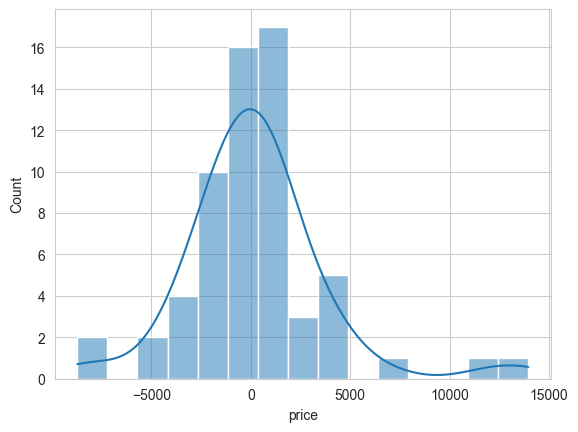

In [185]:
sns.histplot(y_test - y_ridge_test, kde=True)
plt.show()